# 期現套利 HBT：每日持久化跨日 Runner

## Goal

這個 Notebook 是新版 full-market pipeline 的薄 runner。Reference HftBacktest 仍是執行與回歸基準；日期依序處理、同日 pairs 使用同一個常駐 worker pool，未平倉部位以原期貨合約帶入下一日。

`report_mode='summary'` 會在每個日期完成後，把 summary、trades、market、latency、entry/exit、carry 與 errors 原子發布到 `output/core/dates/trade_date=YYYY-MM-DD/`。年度大型明細不留在記憶體；重新執行時只重用 manifest、資料 identity 與 carry chain 全部驗證成功的連續日期。

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

CURRENT_DIR = Path.cwd().resolve()
TEST_ROOT = CURRENT_DIR if (CURRENT_DIR / 'backtest_config.py').exists() else CURRENT_DIR / 'future_spot' / 'test'
if not TEST_ROOT.exists():
    raise FileNotFoundError('Open this notebook from future_spot/test or the repository root')
PROJECT_ROOT = TEST_ROOT.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
for path in (TEST_ROOT, PROJECT_ROOT, WORKSPACE_ROOT, PROJECT_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from backtest_config import default_notebook_args
from backtest_pipeline import run_backtest_pipeline
from report_tables import build_report_tables
from report_plots import save_report_plots
from scripts.daily_result_store import DAILY_RESULT_SCHEMA_VERSION, DailyResultStore
from scripts.io_utils import read_csv_if_exists

## Setup

### 1. 設定日期、延遲、資金與輸出模式

第一次執行會逐日建立結果分區；同一組結果定義再次執行時會驗證並續跑。若程式、資料或參數 identity 改變，請使用新的 `output_dir`，不要覆蓋舊研究結果。

In [2]:
# 這 8 個到期殘倉 run 會從 HBT、交易、績效與資金重播中刪除。
EXCLUDED_RUN_KEYS = {
    '2026-04-15::1802_KUFD6',
    '2026-05-20::6173_PKFE6',
    '2026-07-15::2340_FYFG6',
    '2026-07-15::2408_CYFG6',
    '2026-07-15::3714_QBFG6',
    '2026-07-15::4919_REFG6',
    '2026-07-15::5371_NMFG6',
    '2026-07-15::6257_MQFG6',
}

args = default_notebook_args(
    start_date='2026-01-01',
    end_date='2026-07-31',
    carry_positions=True,
    total_capital=50_000_000.0,
    futures_margin_rate=0.20,
    spot_equity_rate=0.40,
    leverage=False,             # False：期貨與現股皆按 100% 自有資金
    future_order_latency_ms=1.0,
    future_response_latency_ms=1.0,
    future_feed_latency_offset_ms=0.0,
    spot_order_latency_ms=1.0,
    spot_response_latency_ms=35.0,
    spot_feed_latency_offset_ms=0.0,
    low_memory_reports=True,
    report_mode='summary',      # 啟用每日 Parquet、bounded memory 與 verified resume
    report_chunk_rows=25_000,
    continue_on_error=True,
    post_first_feed_wait='spot',
    post_first_feed_timeout_ms=5000.0,
    rebuild_hbt_results=False,
    excluded_run_keys=sorted(EXCLUDED_RUN_KEYS),
)

PLOT_EXCLUDED_DATES = tuple(args.excluded_dates)
print(f'Output: {args.output_dir}')
print(f'Daily result schema: {DAILY_RESULT_SCHEMA_VERSION}')

Output: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms
Daily result schema: 1


## Steps

### 2. 執行或續跑，顯示各階段耗時，並驗證每日 manifest、carry 與錯誤稽核

完整 timing audit 會保存為 `stage_timings.csv`。Notebook 顯示 pipeline 階段、各 stage 統計，以及逐交易日耗時；`date_total` 包含該日所有子階段，不應再與子階段相加。

In [3]:
artifacts = run_backtest_pipeline(args)

stage_timings = artifacts.frame('stage_timings').copy()
stage_timings['elapsed_seconds'] = pd.to_numeric(stage_timings['elapsed_seconds'], errors='coerce')
pipeline_timings = stage_timings.loc[stage_timings['mode'].eq('pipeline')].copy()
timing_summary = (
    stage_timings.loc[stage_timings['stage'].ne('date_total')]
    .groupby(['mode', 'stage'], dropna=False)['elapsed_seconds']
    .agg(calls='size', total_seconds='sum', mean_seconds='mean', max_seconds='max')
    .reset_index()
    .sort_values('total_seconds', ascending=False)
)
daily_timings = (
    stage_timings.loc[stage_timings['trade_date'].notna()]
    .pivot_table(index=['trade_date', 'mode'], columns='stage', values='elapsed_seconds', aggfunc='sum')
    .reset_index()
)

print(f'Stage timing CSV: {artifacts.output_dir / "stage_timings.csv"}')
display(pipeline_timings[['stage', 'elapsed_seconds', 'pair_count']])
display(timing_summary)
display(daily_timings.head(20))
if len(daily_timings) > 20:
    display(daily_timings.tail(20))
result_store = DailyResultStore(artifacts.output_dir / 'core')

manifest_rows = []
for trade_date in artifacts.trade_dates:
    manifest = result_store.validate(trade_date)
    payload = manifest.payload
    manifest_rows.append({
        'trade_date': trade_date,
        'schema_version': payload['schema_version'],
        'engine': payload.get('metadata', {}).get('engine'),
        'time_in_force_semantics': payload.get('metadata', {}).get('time_in_force_semantics'),
        'run_keys': len(payload.get('run_keys', [])),
        'summary_rows': payload.get('tables', {}).get('summary', {}).get('rows', 0),
        'trade_rows': payload.get('tables', {}).get('trades', {}).get('rows', 0),
        'error_rows': payload.get('tables', {}).get('run_errors', {}).get('rows', 0),
        'manifest': str(manifest.path),
    })
daily_manifest_audit = pd.DataFrame(manifest_rows)
if len(daily_manifest_audit) != len(artifacts.trade_dates):
    raise RuntimeError('每日結果不是完整且連續的已驗證日期序列')

display(daily_manifest_audit.head(20))
display(artifacts.frame('summary').head(20))
entry_exit_index = read_csv_if_exists(artifacts.output_dir / 'entry_exit_index.csv')
display(entry_exit_index.head(20))

carry_status = artifacts.frame('position_carry_status')
if not carry_status.empty:
    display(carry_status.loc[carry_status['universe_source'].ne('selected')].head(30))
    expiry_violations = carry_status.loc[carry_status['status'].eq('expiry_position_remaining')].copy()
    if not expiry_violations.empty:
        display(expiry_violations)
        raise RuntimeError(f'期貨到期日仍有殘倉：{len(expiry_violations)} 筆')

run_errors = read_csv_if_exists(artifacts.output_dir / 'run_errors.csv')
print(f'run_errors.csv rows: {len(run_errors):,}')
if not run_errors.empty:
    display(run_errors.head(100))

for frame_name in ('summary', 'position_carry_status'):
    frame = artifacts.frame(frame_name)
    leaked = frame.loc[frame['run_key'].astype(str).isin(EXCLUDED_RUN_KEYS)] if not frame.empty else frame
    if not leaked.empty:
        raise RuntimeError(f'{frame_name} 仍含已排除 run_key：{sorted(leaked.run_key.unique())}')
for trade_date in artifacts.trade_dates:
    trades_for_date = result_store.load_table(trade_date, 'trades')
    if not trades_for_date.empty:
        leaked = trades_for_date.loc[trades_for_date['run_key'].astype(str).isin(EXCLUDED_RUN_KEYS)]
        if not leaked.empty:
            raise RuntimeError(f'trades 仍含已排除 run_key：{sorted(leaked.run_key.unique())}')

print('每日 manifest、跨日 carry、排除 run_key 與錯誤稽核完成。')

Stage timing CSV: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/stage_timings.csv


,stage,elapsed_seconds,pair_count
0,prepare_args,0.000459,0
1,select_trade_dates,0.009976,0
2,build_daily_pair_records,527.983079,4456
3,execute_or_resume_hbt,769.988096,4621
929,persist_audit_frames,0.149479,4621
930,write_backtest_manifest,0.370398,4621
931,entry_exit_handoff,0.000221,4621
932,pipeline_total,1298.524483,4621


,mode,stage,calls,total_seconds,mean_seconds,max_seconds
9,pipeline,pipeline_total,1,1298.524483,1298.524483,1298.524483
7,pipeline,execute_or_resume_hbt,1,769.988096,769.988096,769.988096
5,pipeline,build_daily_pair_records,1,527.983079,527.983079,527.983079
4,executed,pair_matching,132,274.459497,2.079239,6.248772
14,run,compatibility_csv_stream,1,218.397582,218.397582,218.397582
2,executed,event_audit,132,153.862509,1.165625,9.271148
0,executed,carry_and_entry_exit,132,96.107073,0.728084,10.116585
1,executed,daily_result_publish,132,26.014073,0.197076,1.868333
13,resume_check,daily_identity_validation,132,0.423543,0.003209,0.007163
3,executed,event_data,132,0.378169,0.002865,0.145887


stage,trade_date,mode,carry_and_entry_exit,daily_identity_validation,daily_result_publish,date_total,event_audit,event_data,pair_matching
0,2026-01-02,executed,0.000528,NaN,0.011499,0.013838,0.000075,0.000130,0.000155
1,2026-01-02,resume_check,NaN,0.001425,NaN,NaN,NaN,NaN,NaN
2,2026-01-05,executed,0.000607,NaN,0.010413,0.011572,0.000028,0.000071,0.000123
3,2026-01-05,resume_check,NaN,0.000310,NaN,NaN,NaN,NaN,NaN
4,2026-01-06,executed,0.000236,NaN,0.011181,0.012032,0.000029,0.000074,0.000129
5,2026-01-06,resume_check,NaN,0.000367,NaN,NaN,NaN,NaN,NaN
6,2026-01-07,executed,0.000250,NaN,0.011164,0.012025,0.000027,0.000073,0.000127
7,2026-01-07,resume_check,NaN,0.000368,NaN,NaN,NaN,NaN,NaN
8,2026-01-08,executed,0.129617,NaN,0.092481,6.552165,0.075399,0.002433,6.248772
9,2026-01-08,resume_check,NaN,0.003366,NaN,NaN,NaN,NaN,NaN


stage,trade_date,mode,carry_and_entry_exit,daily_identity_validation,daily_result_publish,date_total,event_audit,event_data,pair_matching
244,2026-07-16,executed,0.048618,NaN,0.040090,1.695031,0.185871,0.001748,1.415242
245,2026-07-16,resume_check,NaN,0.003383,NaN,NaN,NaN,NaN,NaN
246,2026-07-17,executed,0.065225,NaN,0.044145,1.690846,0.057313,0.001489,1.519826
247,2026-07-17,resume_check,NaN,0.002781,NaN,NaN,NaN,NaN,NaN
248,2026-07-20,executed,0.071066,NaN,0.049031,2.278651,0.068816,0.001936,2.084336
249,2026-07-20,resume_check,NaN,0.003378,NaN,NaN,NaN,NaN,NaN
250,2026-07-21,executed,0.091347,NaN,0.089677,1.925338,0.067177,0.001801,1.671790
251,2026-07-21,resume_check,NaN,0.003448,NaN,NaN,NaN,NaN,NaN
252,2026-07-23,executed,0.079639,NaN,0.054606,2.146804,0.078648,0.002137,1.927620
253,2026-07-23,resume_check,NaN,0.004070,NaN,NaN,NaN,NaN,NaN


...

,trade_date,run_key,pair_name,rows,entry_signal_rows,entry_execution_rows,exit_execution_rows
0,2026-01-08,2026-01-08::1303_CAFA6,1303_CAFA6,0,0,0,0
1,2026-01-08,2026-01-08::2002_CBFA6,2002_CBFA6,0,0,0,0
2,2026-01-08,2026-01-08::1301_CFFA6,1301_CFFA6,0,0,0,0
3,2026-01-08,2026-01-08::2409_CHFA6,2409_CHFA6,0,0,0,0
4,2026-01-08,2026-01-08::1605_CSFA6,1605_CSFA6,0,0,0,0
5,2026-01-08,2026-01-08::2408_CYFA6,2408_CYFA6,0,0,0,0
6,2026-01-08,2026-01-08::2603_CZFA6,2603_CZFA6,0,0,0,0
7,2026-01-08,2026-01-08::2609_DAFA6,2609_DAFA6,0,0,0,0
8,2026-01-08,2026-01-08::1101_DFFA6,1101_DFFA6,0,0,0,0
9,2026-01-08,2026-01-08::1326_DGFA6,1326_DGFA6,0,0,0,0


,trade_date,run_key,pair_name,spot_symbol,future_symbol,universe_source,carried_from_date,initial_quantity,initial_direction,final_quantity,final_direction,expiry_date,is_expiry_date,carry_to_next_date,status
68,2026-01-09,2026-01-09::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-08,9,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
94,2026-01-12,2026-01-12::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-09,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
116,2026-01-13,2026-01-13::6282_KFFA6,6282_KFFA6,6282,KFFA6,selected+carried,2026-01-12,8,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed
130,2026-01-13,2026-01-13::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-12,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
170,2026-01-14,2026-01-14::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-13,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
202,2026-01-15,2026-01-15::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-14,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
237,2026-01-16,2026-01-16::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-15,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
238,2026-01-19,2026-01-19::1303_CAFA6,1303_CAFA6,1303,CAFA6,selected+carried,2026-01-16,10,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed
273,2026-01-19,2026-01-19::6770_QZFA6,6770_QZFA6,6770,QZFA6,carried_position,2026-01-16,10,ENTER_LONG_SPOT_SHORT_FUTURE,10,ENTER_LONG_SPOT_SHORT_FUTURE,2026-01-21,False,True,carried_forward
298,2026-01-20,2026-01-20::1717_QOFA6,1717_QOFA6,1717,QOFA6,selected+carried,2026-01-19,4,ENTER_LONG_SPOT_SHORT_FUTURE,0,HOLD,2026-01-21,False,False,closed


run_errors.csv rows: 2


,trade_date,run_key,pair_name,spot_symbol,future_symbol,error
0,2026-07-10,2026-07-10::4919_REFG6,4919_REFG6,4919,REFG6,missing converted event data
1,2026-07-10,2026-07-10::6257_MQFG6,6257_MQFG6,6257,MQFG6,missing converted event data


每日 manifest、跨日 carry、排除 run_key 與錯誤稽核完成。


## Results

### 3. 以 bounded CSV chunks 產生資金與績效報表

大型明細已在日期邊界釋放；報表從每日分區串流產生的 compatibility CSV 讀取，不會重跑 HBT。

In [4]:
reports = build_report_tables(artifacts)
display(reports.frame('symbol_profit').head(30))
display(reports.frame('failure_overview'))
display(reports.frame('capital_constraint_summary'))
display(reports.frame('daily_capital_constraint').tail(20))
print(f'Report CSV directory: {reports.output_dir}')

,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
0,2492,22,6,3.476665e+06,158030.224818,284,25,10,24.0
1,2327,99,8,1.318862e+06,13321.841434,484,3,1,190.0
2,2454,14,4,9.857453e+05,70410.377857,106,1,1,50.0
3,6488,10,3,9.791449e+05,97914.492200,334,41,26,69.0
4,3189,78,8,6.426548e+05,8239.163692,524,10,1,121.0
5,4958,97,8,6.346100e+05,6542.370773,344,6,0,119.0
6,3037,79,8,5.290197e+05,6696.452025,396,3,0,119.0
7,6239,45,6,4.355472e+05,9678.827222,144,1,1,43.0
8,2408,105,8,3.918189e+05,3731.608343,774,8,0,176.0
9,2337,91,8,3.734156e+05,4103.467862,554,6,1,66.0


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,159,2082,0,65,96,1886.0


,total_capital,futures_margin_rate,spot_equity_rate,effective_futures_margin_rate,effective_spot_equity_rate,leverage,carry_positions,futures_capital_limit,spot_capital_limit,matched_notional_limit,...,accepted_exits,discarded_open_lots,ending_open_lot_days,capital_filtered_realized_pnl,capital_filtered_realized_roi,peak_spot_capital,peak_futures_capital,peak_total_capital,peak_capital_utilization,replay_scope
0,50000000.0,0.2,0.4,1.0,1.0,False,True,25000000.0,25000000.0,25000000.0,...,4204,6,2262,7.077557e+06,0.141551,2.479039e+07,25000000.0,4.977929e+07,0.995586,continuous_position_candidate_replay


,trade_date,accepted_entries,rejected_entries,accepted_exits,ignored_unmatched_exits,discarded_open_lots,ending_open_lots,realized_pnl,ending_spot_capital,ending_futures_capital,ending_total_capital,peak_spot_capital,peak_futures_capital,peak_total_capital,peak_capital_utilization
84,2026-06-08,21,0,41,0,0,10,2.287214e+04,9.783902e+05,986000.0,1.964390e+06,7.811115e+06,7886000.0,1.569712e+07,0.313942
85,2026-06-09,11,0,21,0,0,0,4.785285e+03,2.008164e-08,0.0,2.008164e-08,1.252400e+06,1264000.0,2.516400e+06,0.050328
86,2026-06-10,10,0,10,0,0,0,2.075993e+04,2.025627e-08,0.0,2.025627e-08,4.723884e+06,4800000.0,9.523884e+06,0.190478
87,2026-06-16,35,0,35,0,0,0,5.722584e+04,2.054730e-08,0.0,2.054730e-08,1.518606e+07,15370000.0,3.055606e+07,0.611121
88,2026-06-17,10,0,10,0,0,0,2.676403e+03,2.057641e-08,0.0,2.057641e-08,7.741087e+05,782000.0,1.556109e+06,0.031122
89,2026-06-18,30,0,0,0,0,30,0.000000e+00,1.014084e+07,10274200.0,2.041504e+07,1.014084e+07,10274200.0,2.041504e+07,0.408301
90,2026-06-22,70,230,33,17,0,67,1.591401e+04,2.005670e+07,20319100.0,4.037580e+07,2.466974e+07,24989500.0,4.965924e+07,0.993185
91,2026-06-23,93,131,61,172,0,99,5.339186e+04,2.465783e+07,24918600.0,4.957643e+07,2.466174e+07,24985500.0,4.964724e+07,0.992945
92,2026-06-25,146,10,184,145,0,61,2.082792e+06,2.459921e+07,24833400.0,4.943261e+07,2.465783e+07,24984000.0,4.957643e+07,0.991529
93,2026-06-26,20,15,64,29,0,17,6.567599e+05,3.949775e+06,3993600.0,7.943375e+06,2.469025e+07,24977400.0,4.966765e+07,0.993353


Report CSV directory: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/reports


## 4. 儲存 PNG 圖表

Plot excluded dates: 2026-04-23, 2026-05-04, 2026-05-19, 2026-06-24, 2026-07-01, 2026-07-22, 2026-07-27
Plot exclusion audit: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/plot_exclusions.csv
portfolio_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/portfolio_overview.png


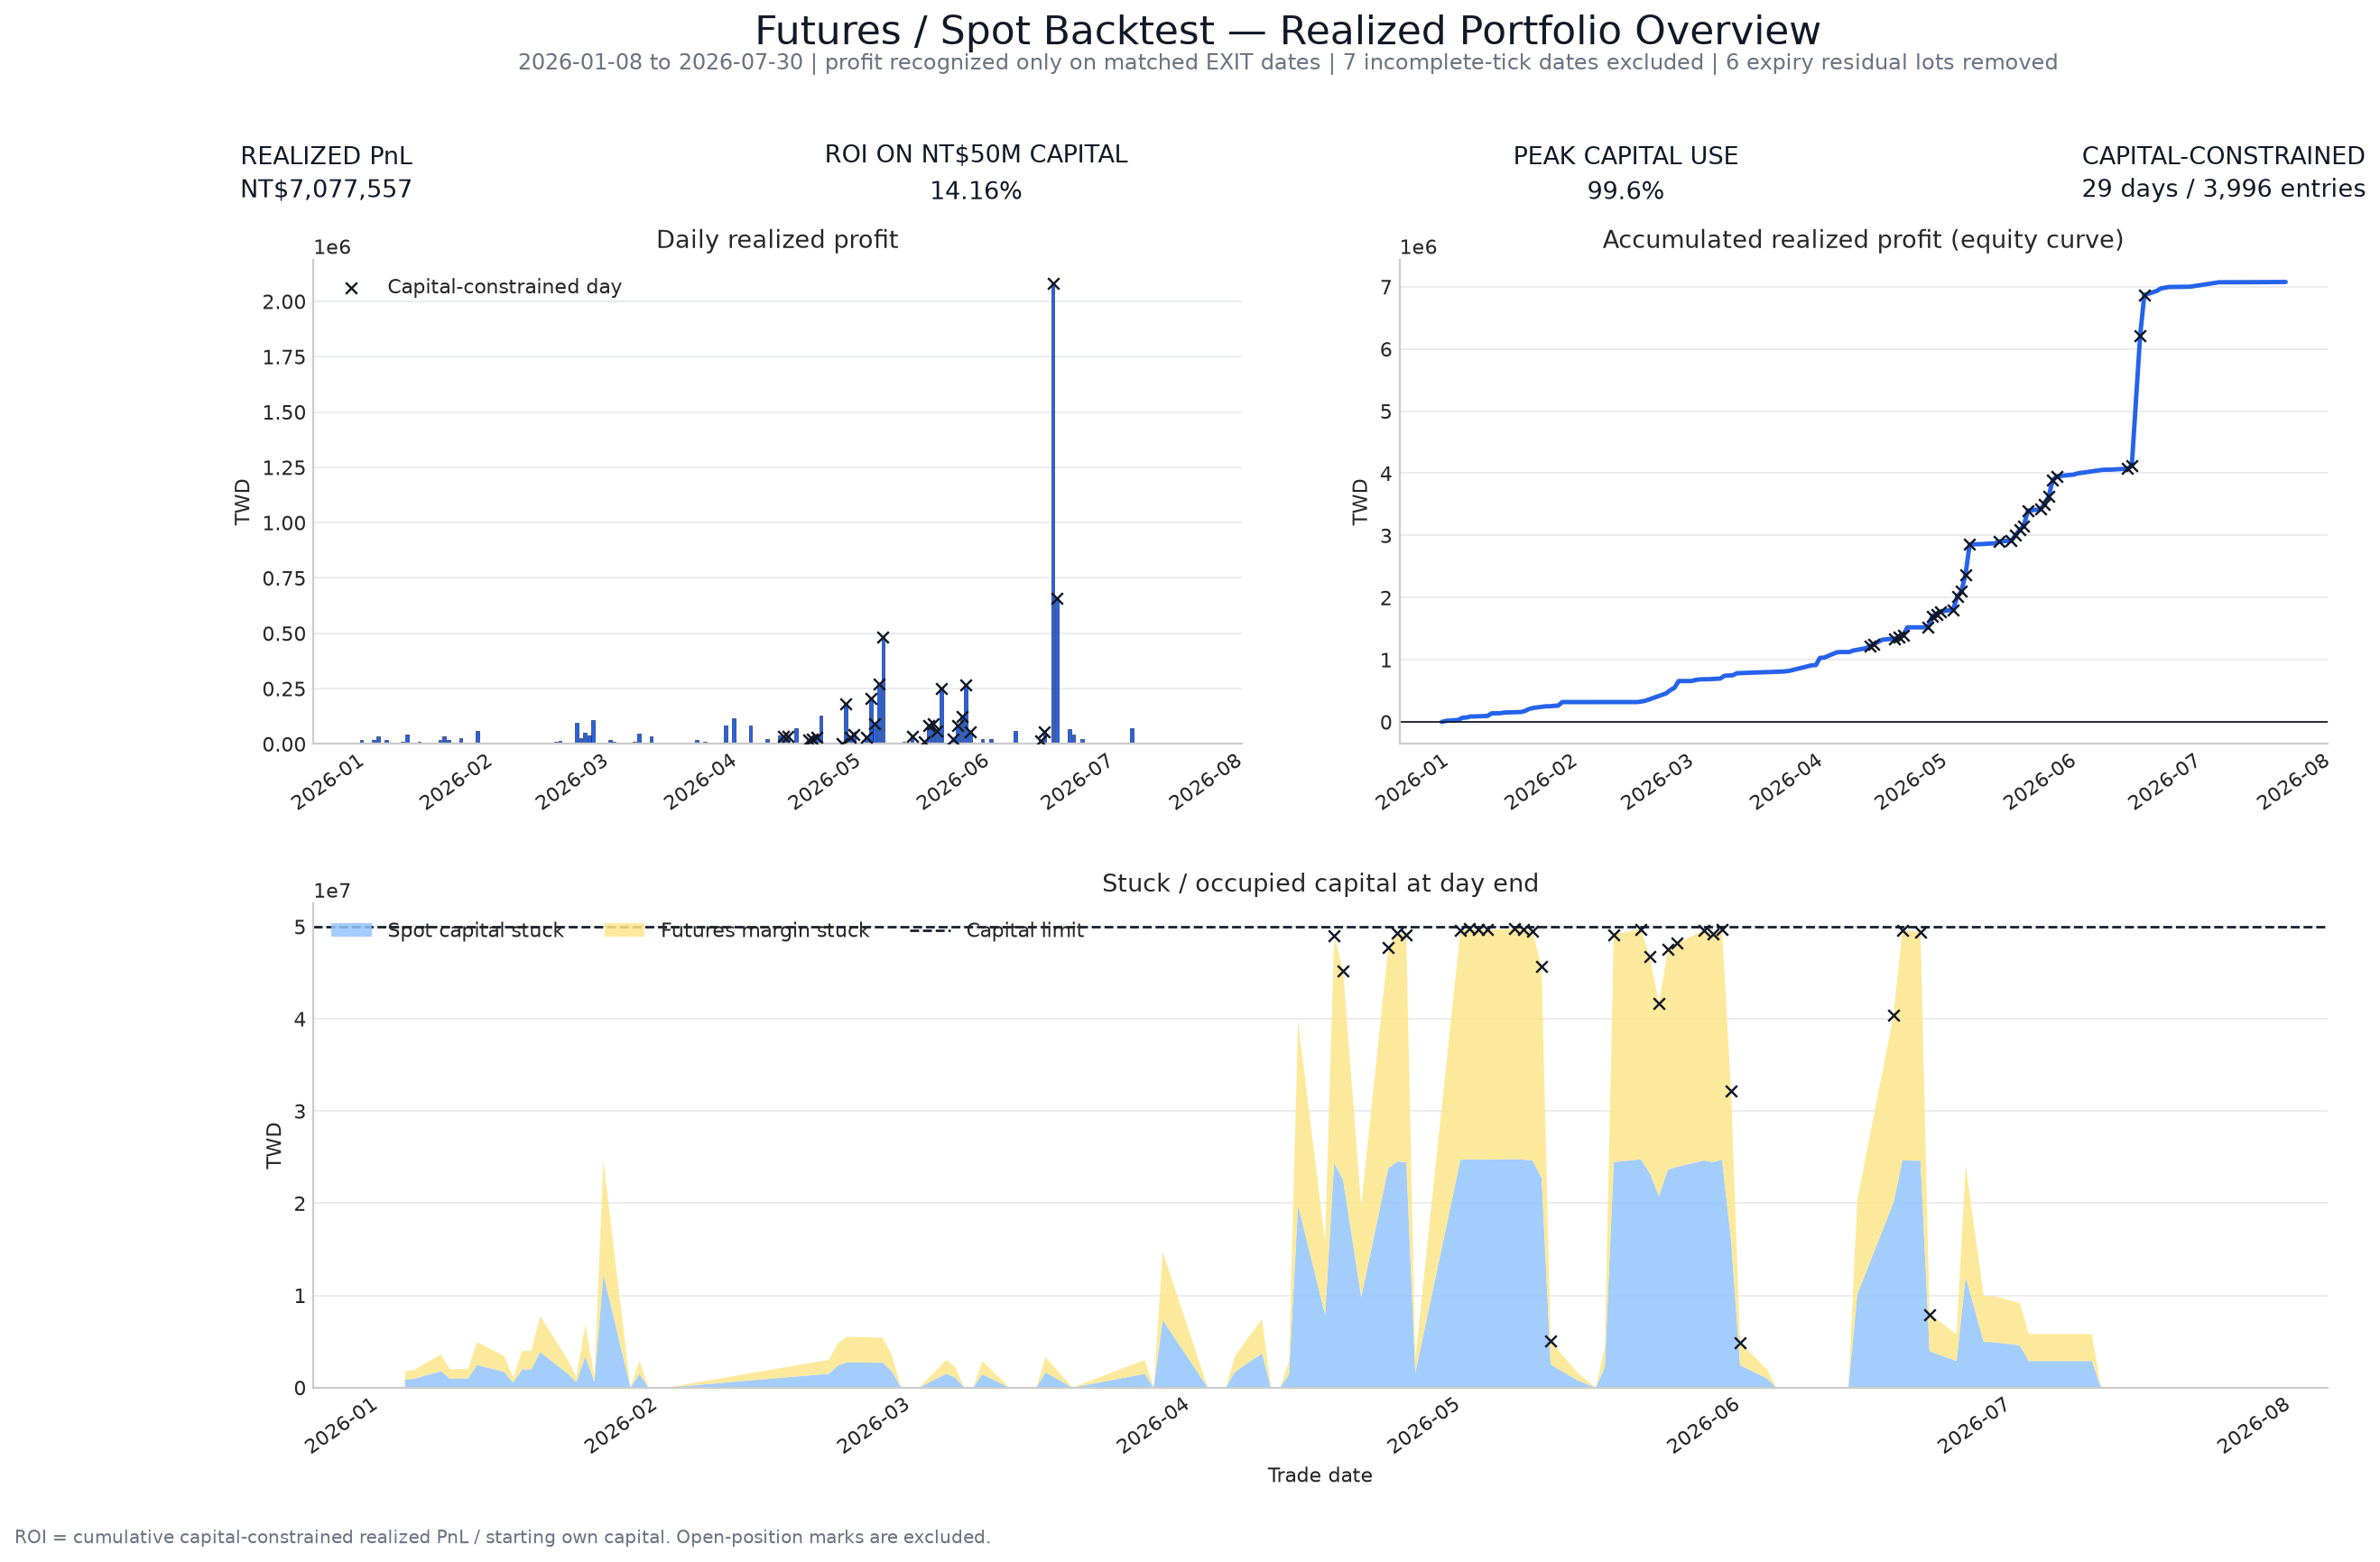

performance_overview: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/performance_overview.png


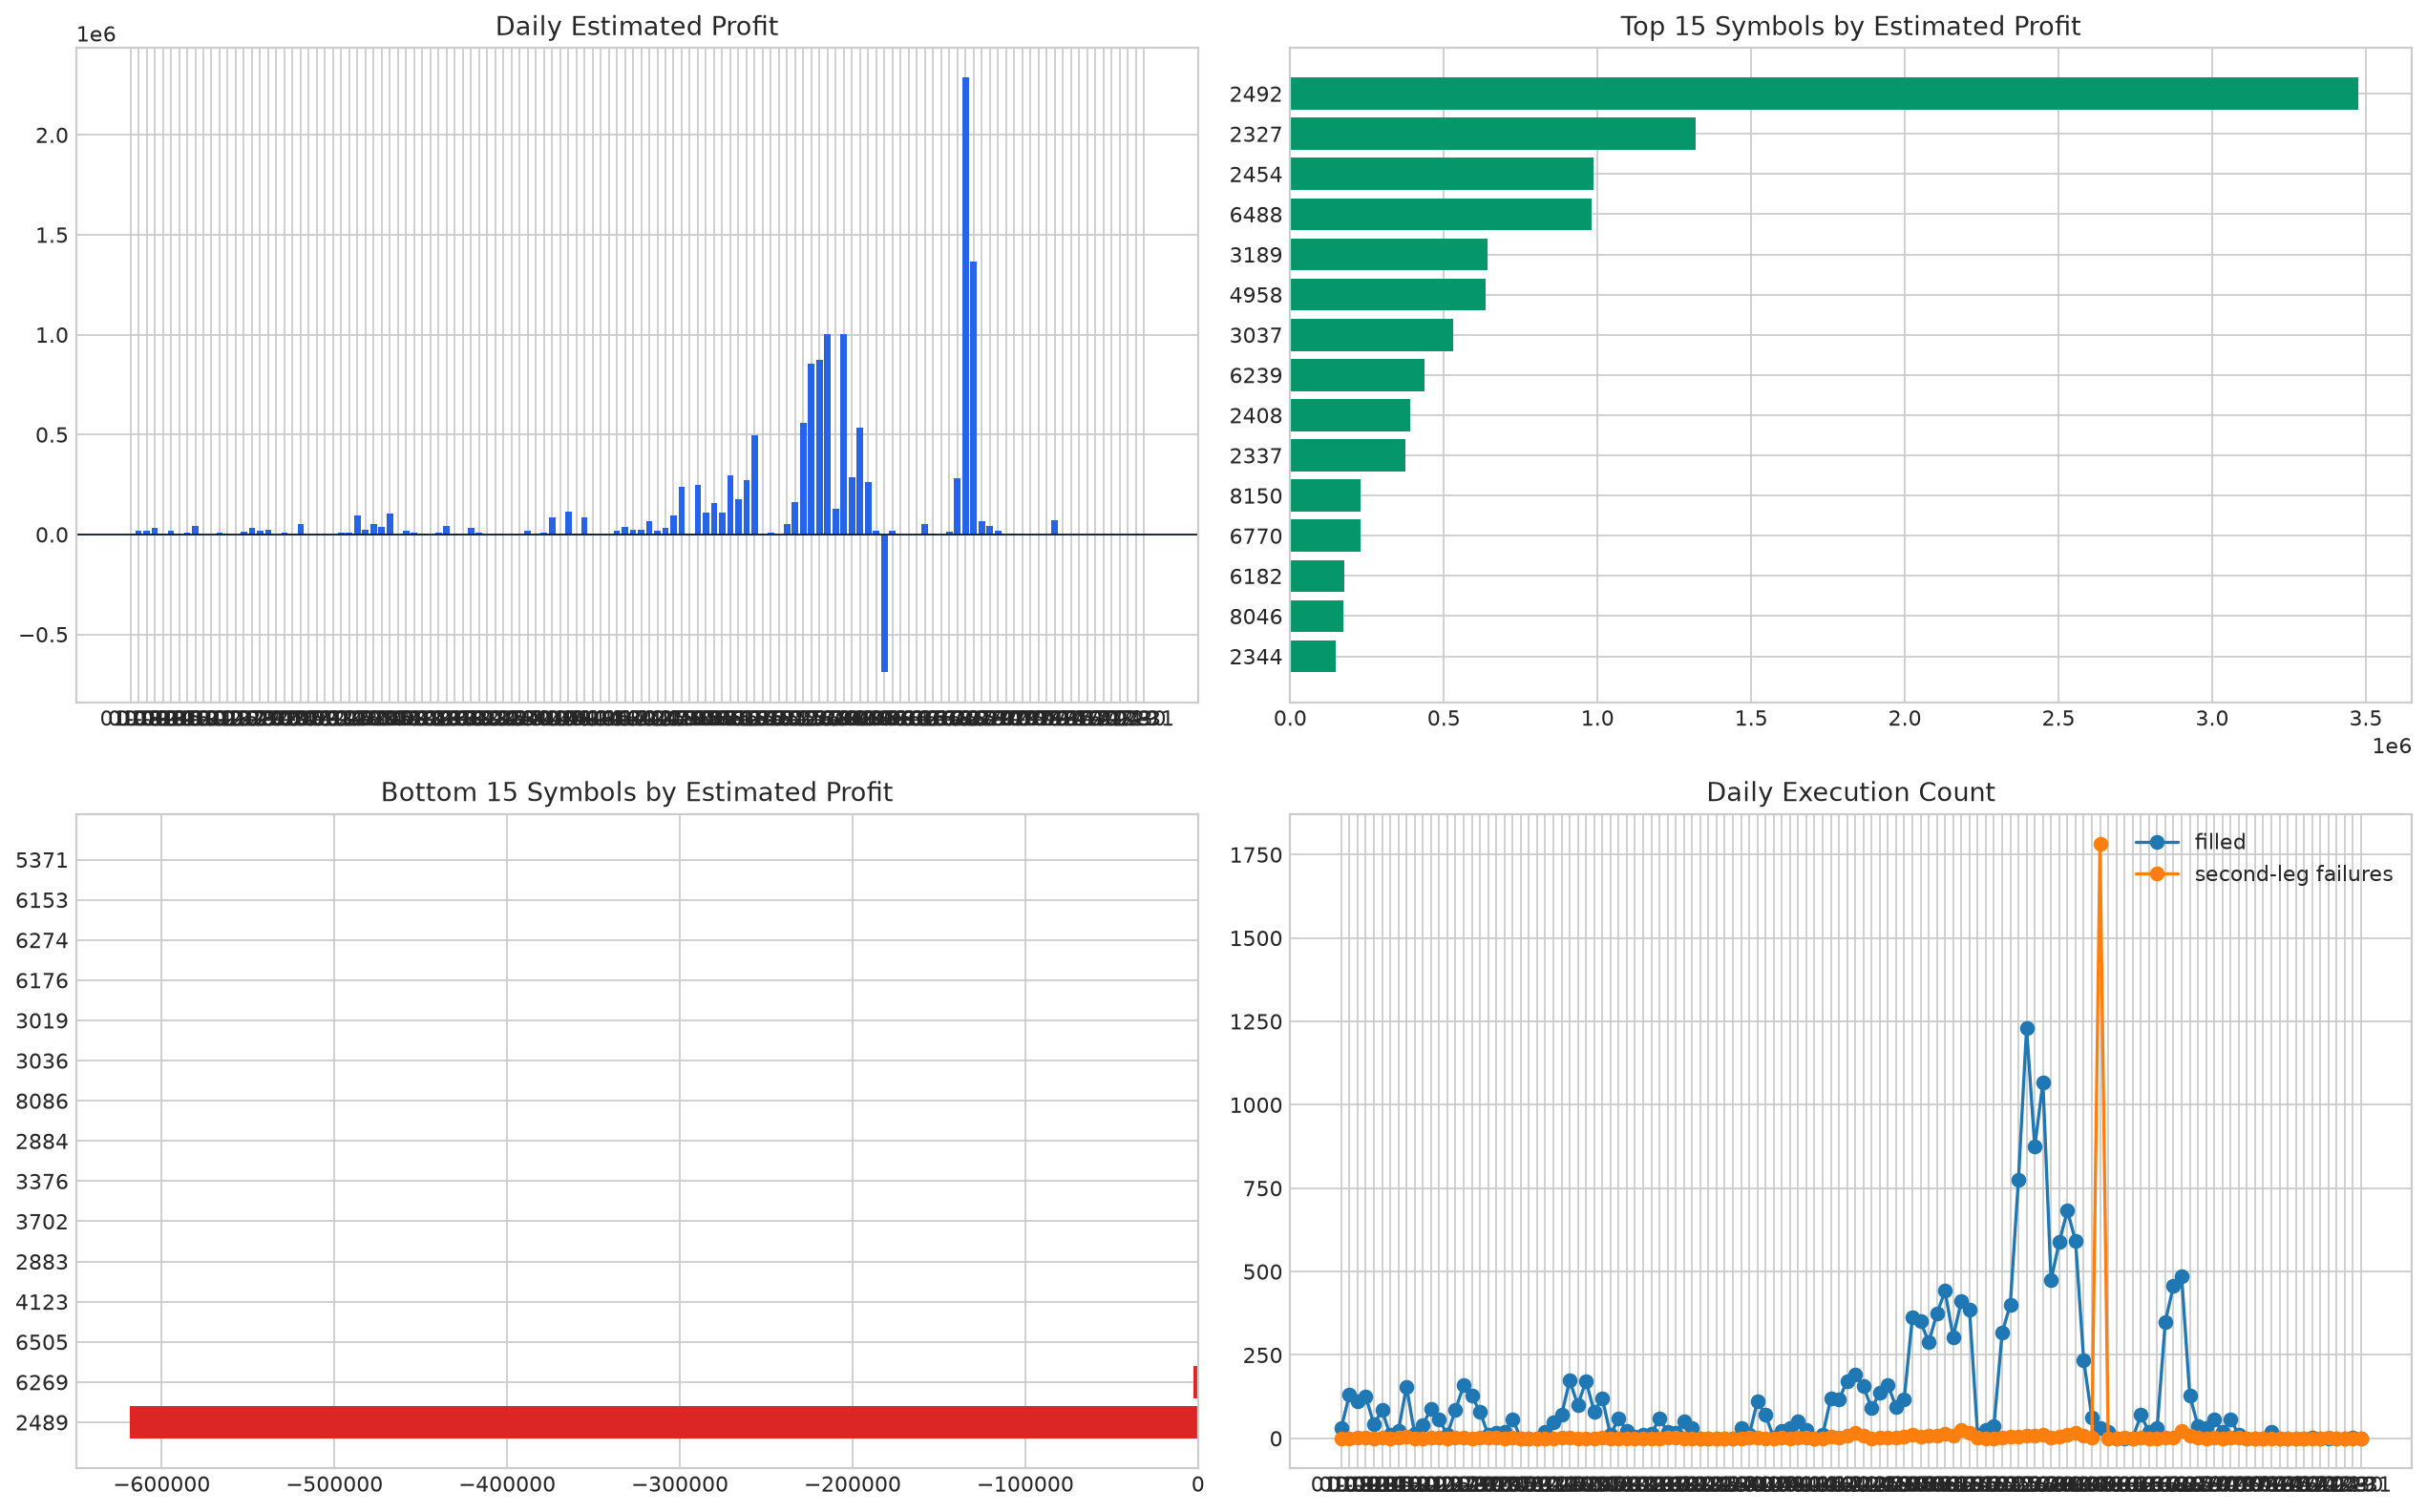

pair_profit_scatter: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/pair_profit_scatter.png


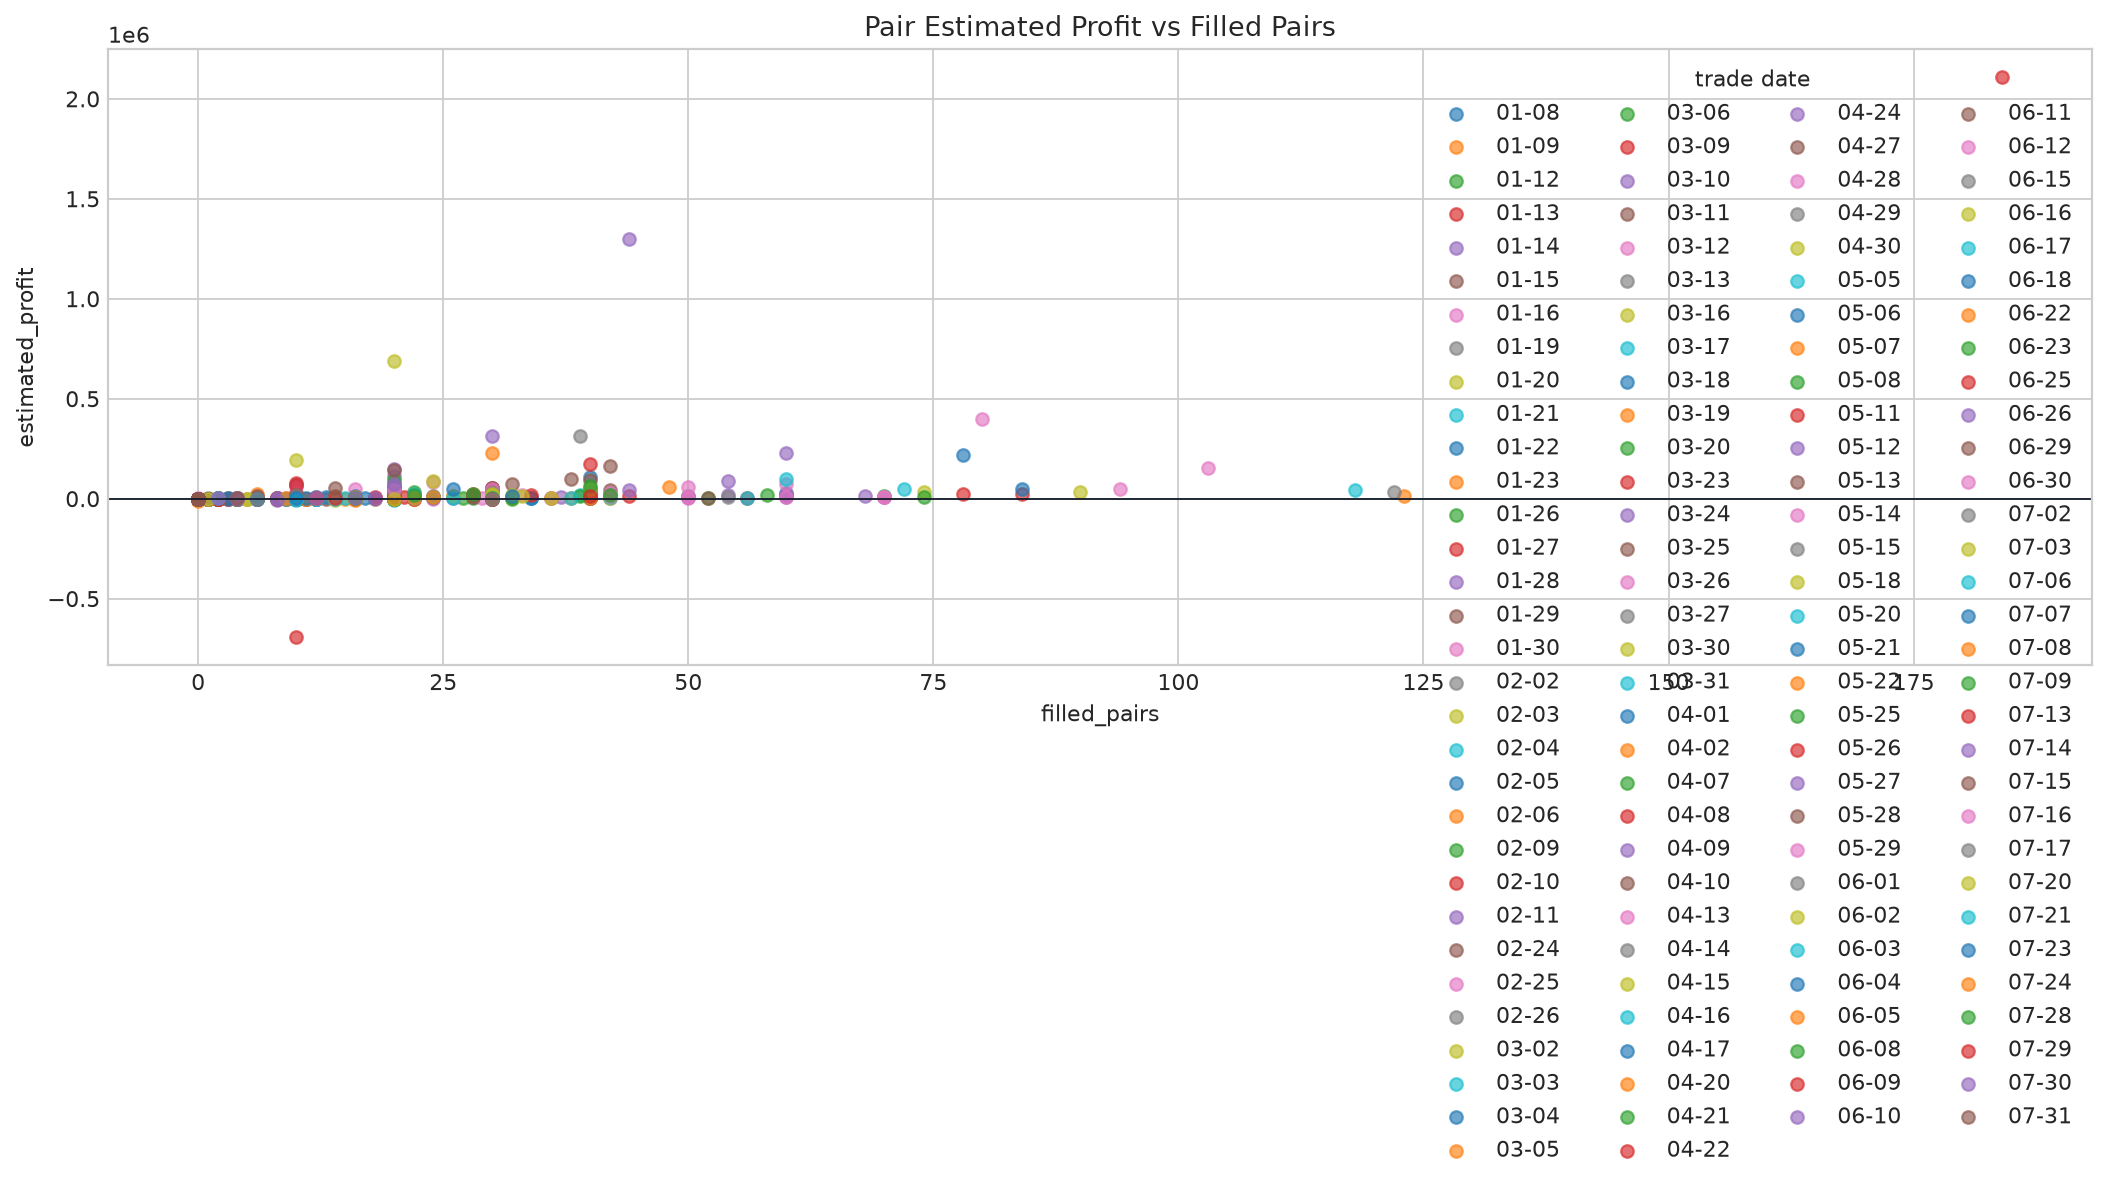

stuck_cash: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/stuck_cash.png


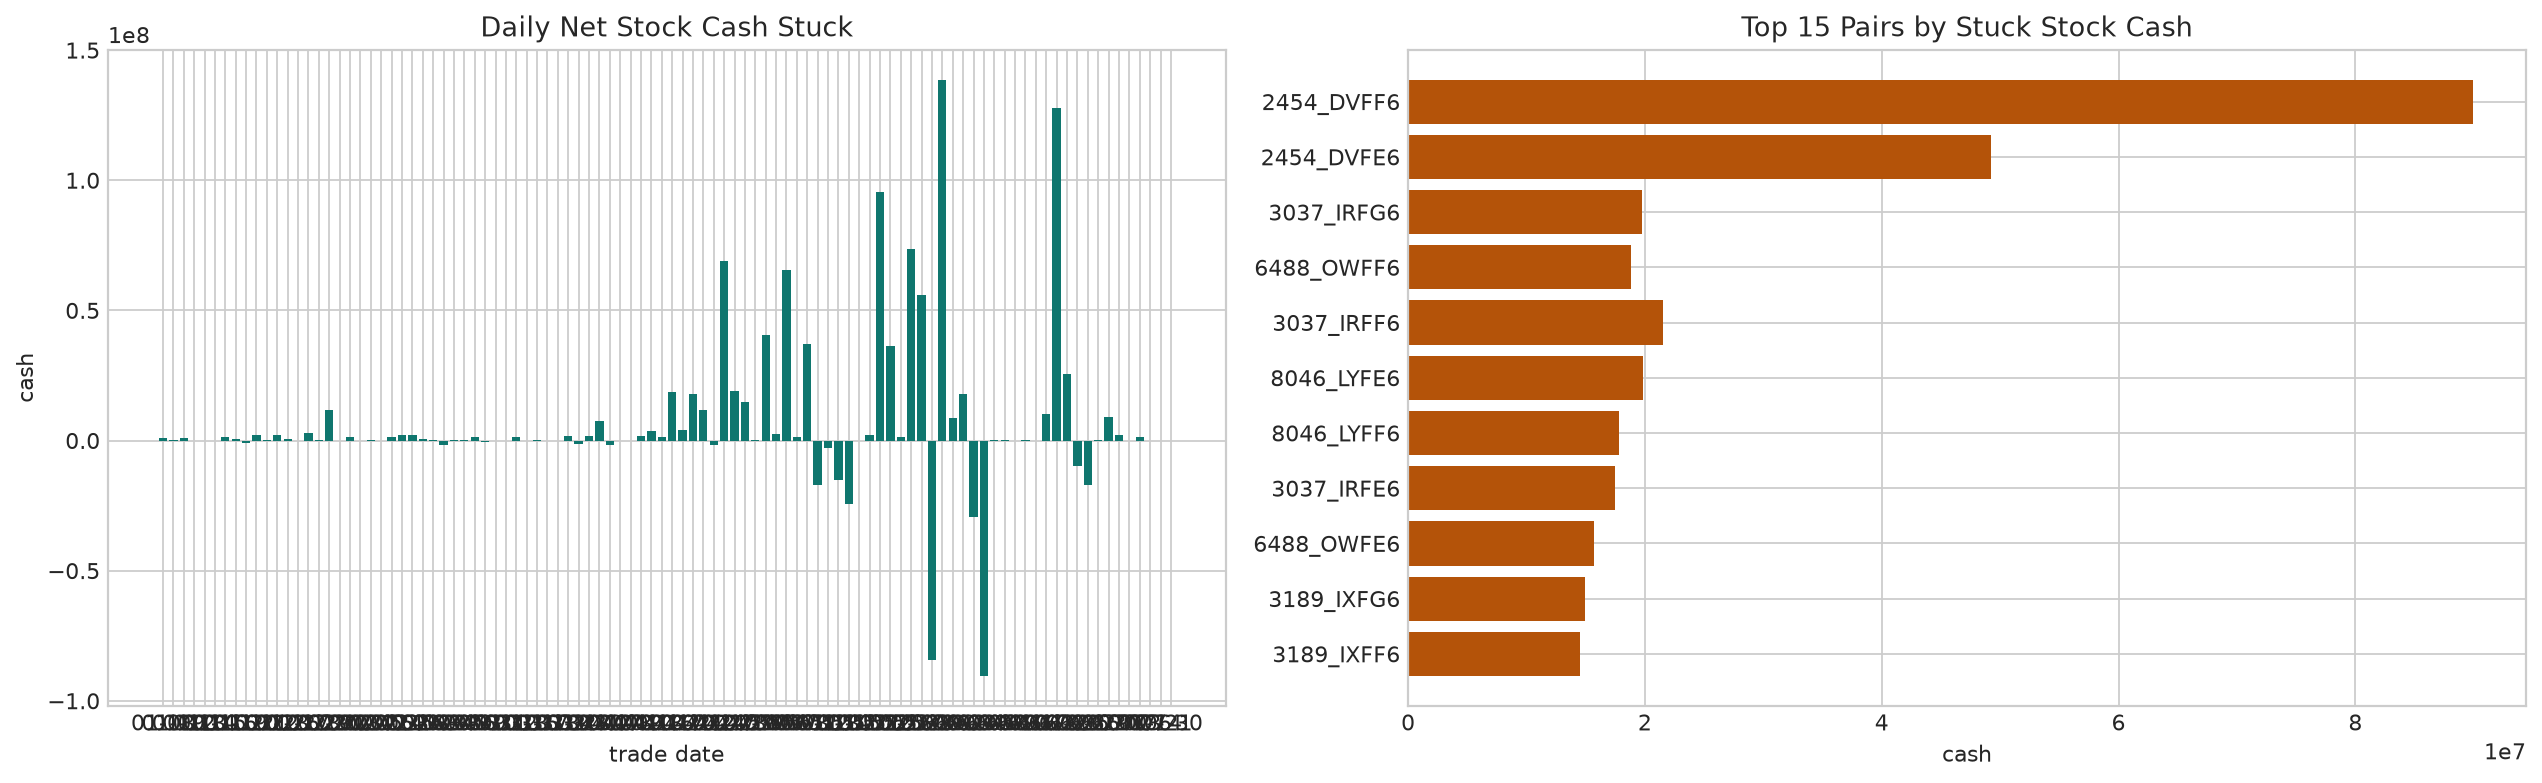

latency_timelines: /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260101_20260731_future_order_1ms_response_1ms_feed_0ms_spot_order_1ms_response_35ms_feed_0ms/figures/latency_timelines.png


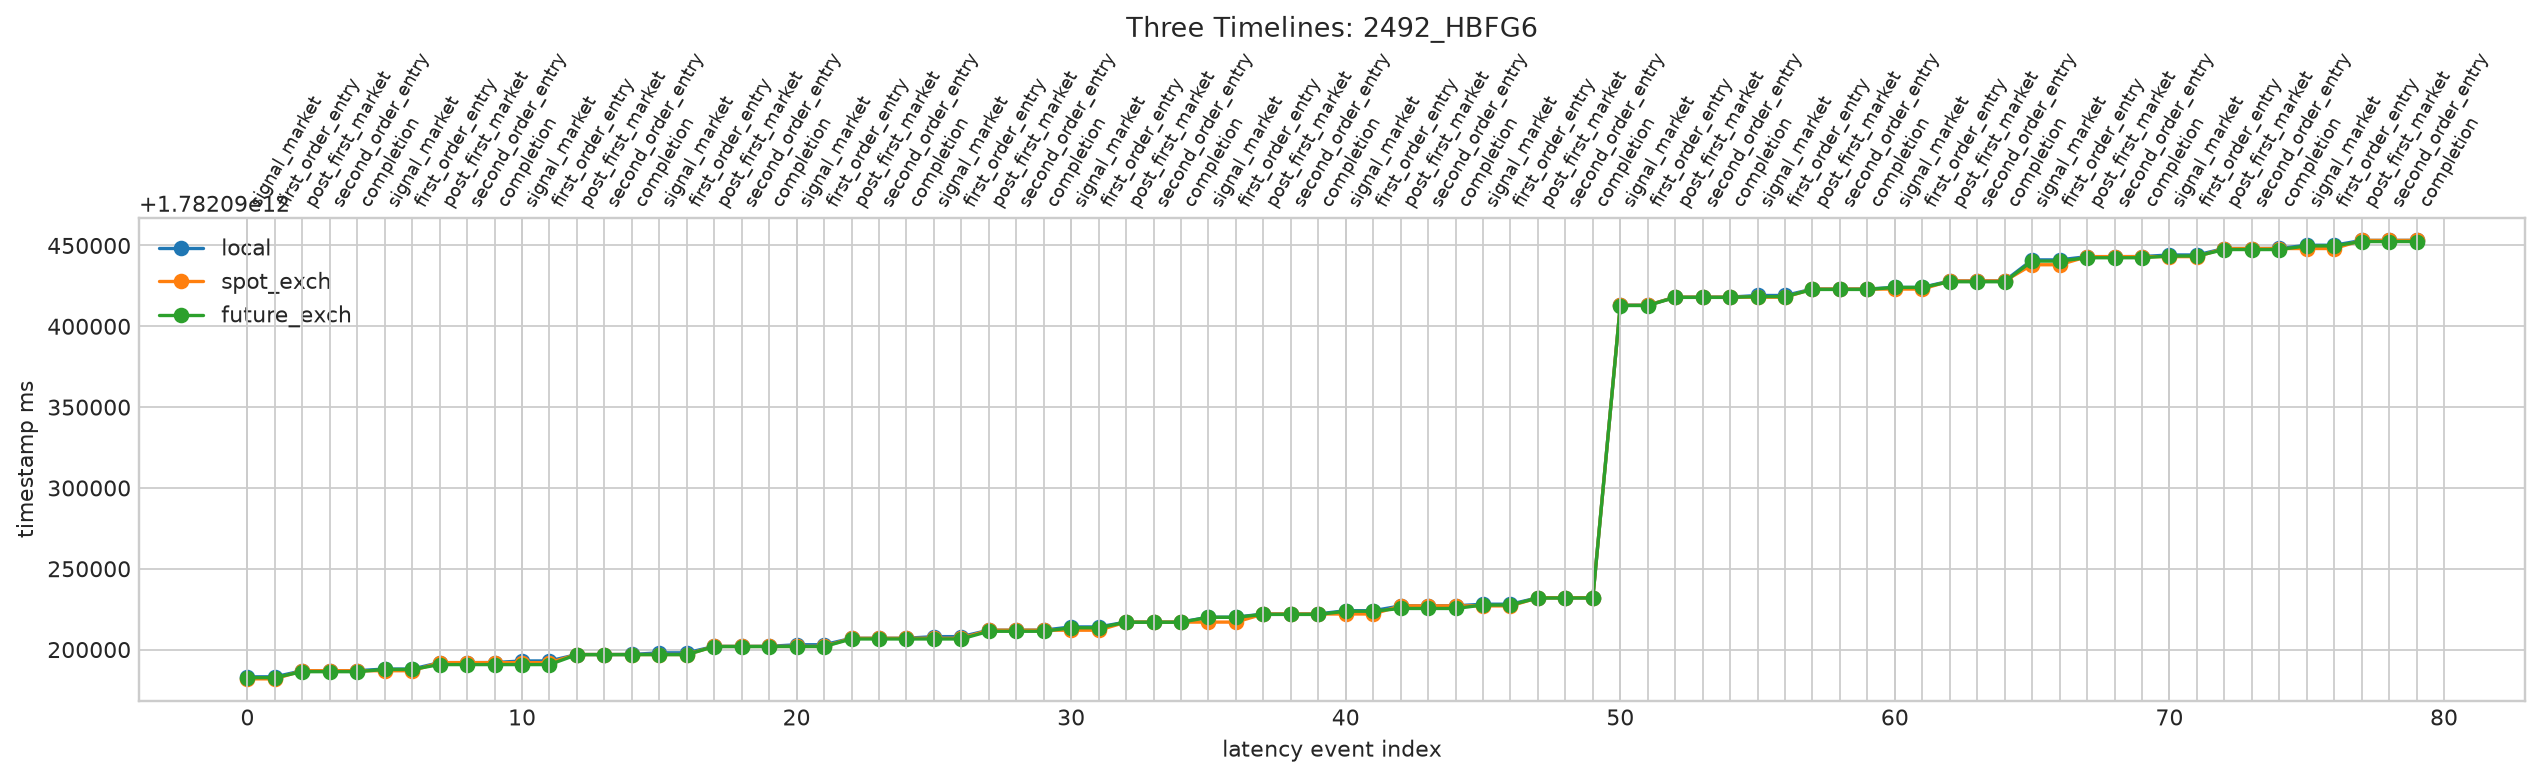

In [5]:
figure_paths = save_report_plots(artifacts, reports, excluded_dates=PLOT_EXCLUDED_DATES)
print(f'Plot excluded dates: {", ".join(PLOT_EXCLUDED_DATES)}')
print(f'Plot exclusion audit: {artifacts.output_dir / "figures" / "plot_exclusions.csv"}')
for name, path in figure_paths.items():
    print(f'{name}: {path}')
    display(Image(filename=str(path)))

## Checks

### 5. 選擇性逐 pair 檢查

逐 pair 明細以 chunks 掃描 compatibility CSV，只保留選定 pair 的前幾筆，不重新載入整年度資料。

In [6]:
def selected_pair_rows(csv_path, pair_name, limit, chunk_rows=25_000):
    if pair_name is None or not csv_path.exists() or csv_path.stat().st_size == 0:
        return pd.DataFrame()
    selected = []
    try:
        chunks = pd.read_csv(csv_path, chunksize=chunk_rows, low_memory=False)
        for chunk in chunks:
            if 'pair_name' not in chunk.columns:
                return pd.DataFrame()
            rows = chunk.loc[chunk['pair_name'].astype(str).eq(str(pair_name))]
            if not rows.empty:
                selected.append(rows.head(limit - sum(len(frame) for frame in selected)))
            if sum(len(frame) for frame in selected) >= limit:
                break
    except pd.errors.EmptyDataError:
        return pd.DataFrame()
    return pd.concat(selected, ignore_index=True, sort=False) if selected else pd.DataFrame()


selected_pair = reports.selected_pair
if selected_pair is None:
    print('No pair is available for drill-down.')
else:
    print(f'Selected pair: {selected_pair}')
    entry_exit_rows = selected_pair_rows(
        artifacts.output_dir / 'entry_exit_all_daily_pairs.csv', selected_pair, 100
    )
    latency_rows = selected_pair_rows(
        artifacts.output_dir / 'latency_all_daily_pairs.csv', selected_pair, 120
    )
    display(entry_exit_rows)
    display(latency_rows)

Selected pair: 2492_HBFG6


,trade_date,run_key,time,pair_name,spot_symbol,future_symbol,entry_signal,spot_bid,spot_ask,spot_ask_size,...,first_side,first_requested_price,first_exec_price,first_exec_qty,second_leg,second_side,second_requested_price,second_exec_price,second_exec_qty,first_to_second_exch_ms
0,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:03.153000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:06.951000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,NaN,...,sell,587.0,587.0,1.0,stock,buy,582.0,580.0,2.0,3762.000128
2,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:07.951000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,69.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:11.969000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,NaN,...,sell,589.0,589.0,1.0,stock,buy,582.0,580.0,2.0,3982.000128
4,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:03:12.969000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,74.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:04:37.083000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,23.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:04:38.083000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:04:38.083000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,2026-06-22,2026-06-22::2492_HBFG6,2026-06-22 09:04:39.083000+08:00,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,579.0,580.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,trade_date,run_key,timestamp,step,pair_name,spot_symbol,future_symbol,signal,status,failure_reason,...,spot_feed_latency_ns,future_exch_ts,future_feed_local_ts,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns,time
0,2026-06-22,2026-06-22::2492_HBFG6,1782090183153000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,SIGNAL,NaN,...,0,1782090182654000000,1782090182654000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-22 09:03:03.153000+08:00
1,2026-06-22,2026-06-22::2492_HBFG6,1782090183155000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,FIRST_ORDER_RESPONSE,NaN,...,0,1782090182654000000,1782090182654000000,0,1.782090e+18,1.782090e+18,1.782090e+18,1000000.0,1000000.0,2026-06-22 09:03:03.153000+08:00
2,2026-06-22,2026-06-22::2492_HBFG6,1782090186915000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,POST_FIRST_MARKET,NaN,...,0,1782090186326000000,1782090186326000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-22 09:03:06.915000+08:00
3,2026-06-22,2026-06-22::2492_HBFG6,1782090186951000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,SECOND_ORDER_RESPONSE,NaN,...,0,1782090186326000000,1782090186326000000,0,1.782090e+18,1.782090e+18,1.782090e+18,1000000.0,35000000.0,2026-06-22 09:03:06.915000+08:00
4,2026-06-22,2026-06-22::2492_HBFG6,1782090186951000000,183,2492_HBFG6,2492,HBFG6,ENTER_LONG_SPOT_SHORT_FUTURE,FILLED,NaN,...,0,1782090186326000000,1782090186326000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-22 09:03:06.951000+08:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2026-06-23,2026-06-23::2492_HBFG6,1782176493051000000,64,2492_HBFG6,2492,HBFG6,EXIT,SIGNAL,NaN,...,0,1782176493028000000,1782176493028000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-23 09:01:33.051000+08:00
116,2026-06-23,2026-06-23::2492_HBFG6,1782176493053000000,64,2492_HBFG6,2492,HBFG6,EXIT,FIRST_ORDER_RESPONSE,NaN,...,0,1782176493028000000,1782176493028000000,0,1.782176e+18,1.782176e+18,1.782176e+18,1000000.0,1000000.0,2026-06-23 09:01:33.051000+08:00
117,2026-06-23,2026-06-23::2492_HBFG6,1782176497033000000,64,2492_HBFG6,2492,HBFG6,EXIT,POST_FIRST_MARKET,NaN,...,0,1782176496373000000,1782176496373000000,0,NaN,NaN,NaN,NaN,NaN,2026-06-23 09:01:37.033000+08:00
118,2026-06-23,2026-06-23::2492_HBFG6,1782176497069000000,64,2492_HBFG6,2492,HBFG6,EXIT,SECOND_ORDER_RESPONSE,NaN,...,0,1782176496373000000,1782176496373000000,0,1.782176e+18,1.782176e+18,1.782176e+18,1000000.0,35000000.0,2026-06-23 09:01:37.033000+08:00


## Next Steps

先把 `start_date`／`end_date` 設成一個交易日並限制少量 pairs，確認 daily manifest、carry 與 `run_errors.csv`；通過後再擴至月份或全年。Compact Arrow cache 與 Slim Rust engine 上線前，這個 Notebook 仍明確使用 Reference engine。